In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [9]:
import os
print(os.listdir(path))

['chest_xray']


In [15]:
import pandas as pd
path1=os.path.join(path,"chest_xray")
print(os.listdir(path1))
print(path1)

['chest_xray', '__MACOSX', 'val', 'test', 'train']
/kaggle/input/chest-xray-pneumonia/chest_xray


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [20]:
train_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
test_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"
val_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"

In [21]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [22]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


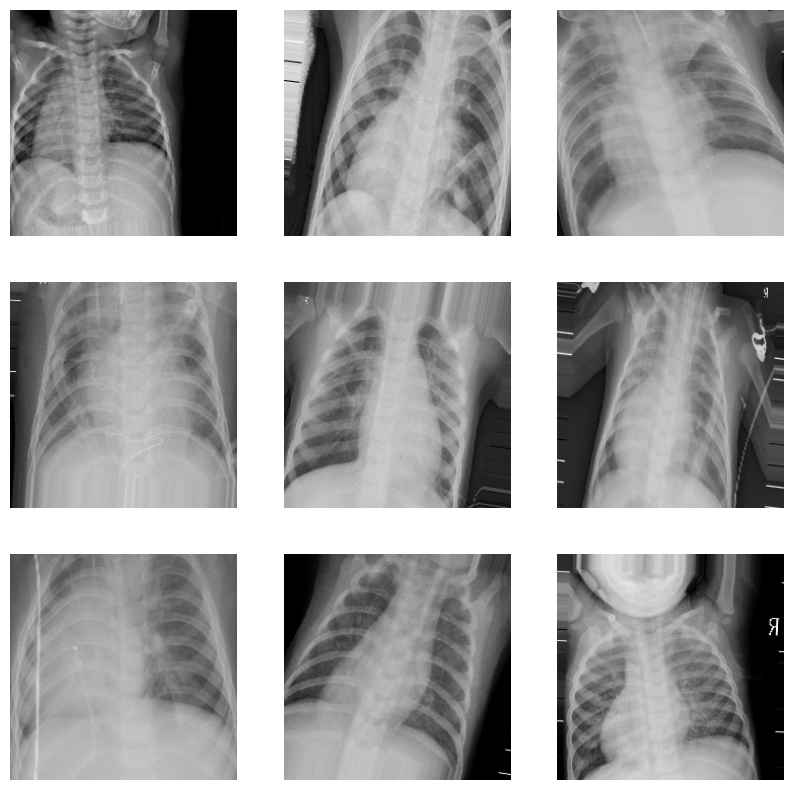

In [23]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

##CNN Model

In [24]:
cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [28]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 802ms/step - accuracy: 0.8160 - loss: 0.4051 - val_accuracy: 0.8125 - val_loss: 0.5632 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.8629 - loss: 0.3126 - val_accuracy: 0.6875 - val_loss: 0.8187 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 624ms/step - accuracy: 0.8827 - loss: 0.2788 - val_accuracy: 0.6875 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.9026 - loss: 0.2402 - val_accuracy: 0.8125 - val_loss: 0.5309 - learning_rate: 2.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 630ms/step - accuracy: 0.9126 - loss: 0.2205 - val_accuracy: 0.8125 - val_loss: 0.5594 - learning_rate: 2.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 657ms/step - accuracy: 0.9101 - loss: 0.2153 - val_accuracy: 0.7500 - val_loss: 0.6421 - learning_rate: 2.0000e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 651ms/s

In [29]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_generator)

print("CNN Accuracy:", cnn_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 335ms/step - accuracy: 0.8782 - loss: 0.3123
CNN Accuracy: 0.8782051205635071


##Transfer Learning

In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [32]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [33]:
for layer in base_model.layers:
    layer.trainable = False

In [34]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

predictions = Dense(
    1,
    activation='sigmoid'
)(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [35]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [36]:
transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 720ms/step - accuracy: 0.9007 - loss: 0.2339 - val_accuracy: 0.7500 - val_loss: 0.3089 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 652ms/step - accuracy: 0.9387 - loss: 0.1574 - val_accuracy: 0.8125 - val_loss: 0.3896 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 636ms/step - accuracy: 0.9383 - loss: 0.1528 - val_accuracy: 0.8125 - val_loss: 0.3528 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 633ms/step - accuracy: 0.9534 - loss: 0.1226 - val_accuracy: 0.8125 - val_loss: 0.2813 - learning_rate: 2.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 633ms/step - accuracy: 0.9536 - loss: 0.1197 - val_accuracy: 0.8125 - val_loss: 0.3161 - learning_rate: 2.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.9536 - loss: 0.1126 - val_accuracy: 0.8125 - val_loss: 0.3141 - learning_rate: 2.0000e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 651ms/s

In [37]:
tl_loss, tl_acc = transfer_model.evaluate(test_generator)

print("Transfer Learning Accuracy:", tl_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.8910 - loss: 0.2530
Transfer Learning Accuracy: 0.8910256624221802


In [38]:
print("CNN Accuracy:", cnn_acc)
print("Transfer Learning Accuracy:", tl_acc)

CNN Accuracy: 0.8782051205635071
Transfer Learning Accuracy: 0.8910256624221802


##Saving Best Model

In [39]:
transfer_model.save("pneumonia_model.h5")

In [40]:
from google.colab import files

files.download("pneumonia_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>